https://velog.io/@kungsboy/%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D-01.%EC%84%A0%ED%98%95%ED%9A%8C%EA%B7%80

In [7]:
# 선형회귀 수업에서 추천 순서
# 두 점으로 기울기 계산
# 절편 계산
# 직선식 작성
# 직선이 모든 점을 통과하지 못함 확인
# 오차(Error) 소개
# SSE 소개
# 최소제곱법(OLS) 소개
# sklearn 실습

# 이 순서로 가면 학생들이 "왜 OLS가 필요한가?"

In [ ]:
# 선형 회귀의 이해
# 원인과 결과의 관계를 선으로 그리는 작업
# 원인이 되는 데이터 (X) vs 결과를 나타내는 데이터 (Y)
# 마법의 직선을 찾는 과정임(가장 훌륭한 예측선 찾기)

# 선형 회귀는 주어진 데이터로부터 와 의 관계를 가장 잘 나타내는 직선을 그리는 일


In [9]:
import numpy as np


# 공부한 시간과 점수를 각각 x, y라는 이름의 넘파이 배열로 만듭니다.
x = np.array([2, 4, 6, 8])
y = np.array([81, 93, 91, 97]) 


#x의 평균값을 구합니다.
mx = np.mean(x)

#y의 평균값을 구합니다.
my = np.mean(y)

# 출력으로 확인합니다.
print("x의 평균값:", mx)
print("y의 평균값:", my)

x의 평균값: 5.0
y의 평균값: 90.5


   study  score
0      1     55
1      2     65
2      3     70
3      4     80
4      5     90


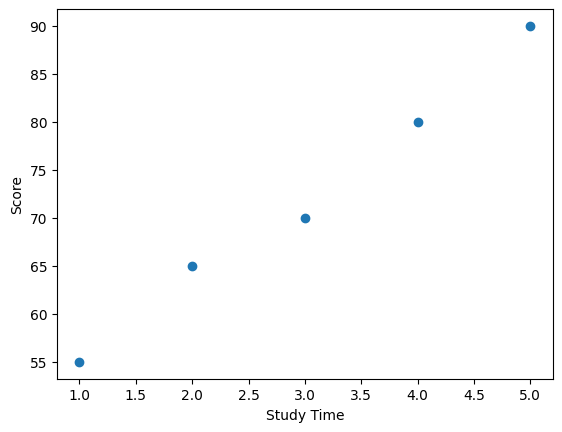

0.9948497511671098
0.00044334353831208687


In [10]:
# 1.회귀란 무엇인가?

# 공부시간과 시험점수
import pandas as pd

df = pd.DataFrame({
    "study":[1,2,3,4,5],
    "score":[55,65,70,80,90]
})

print(df)

#질문) 공부시간이 증가할수록 점수는 증가하는가?

import matplotlib.pyplot as plt

plt.scatter(df["study"],df["score"])

plt.xlabel("Study Time")
plt.ylabel("Score")

plt.show()

# 상관관계
from scipy import stats

corr,p = stats.pearsonr(
    df["study"],
    df["score"]
)

print(corr) # 강한 상관관계를 가진다.
print(p)

In [ ]:
# 선형회귀 모델 만들기
from sklearn.linear_model import LinearRegression

x = df[["study"]]
y = df["score"]

model = LinearRegression()

model.fit(x,y)
print(model.coef_) # 기울기
print(model.intercept_) # 절편

# score= 45 + 8.5×study


[8.5]
46.499999999999986


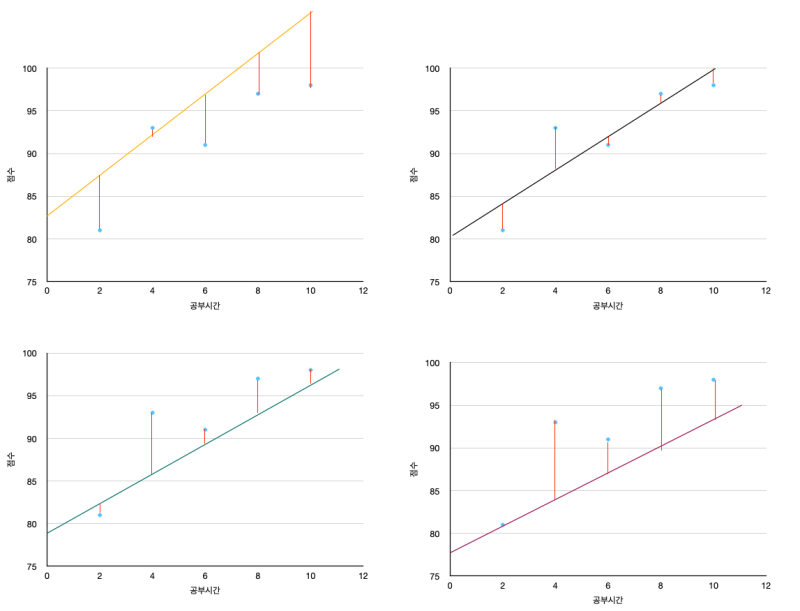

In [ ]:
import numpy as np 
from sklearn.linear_model import LinearRegression 

# 데이터 준비 
# 👉 (5행, 1열) = (샘플 개수, feature 개수)

# | 값  | 의미                |
# | -- | ----------------- |
# | 5행 | 데이터 5개 (샘플 5개)    |
# | 1열 | feature 1개 (x 하나) |

# Scikit-learn은 입력을 반드시 이렇게 기대함:
# (샘플 개수, feature 개수)

X = np.array([[1], [2], [3], [4], [5]]) 
y = np.array([2, 4, 6, 8, 10]) 

# 모델 생성 
model = LinearRegression() 

# 학습 
# 1. 평균 계산
# 2. 기울기 계산
# 3. 절편 계산
# 4. model.coef_ 저장
# 5. model.intercept_ 저장
model.fit(X, y) 

# 예측 
pred = model.predict([[6]]) 
print("기울기:", model.coef_) 
print("절편:", model.intercept_) 
print("예측값:", pred)

기울기: [2.]
절편: 0.0
예측값: [12.]


In [ ]:
#사이킷럿 없이 구현
import pandas as pd

df = pd.DataFrame({
    "study":[1,2,3,4,5],
    "score":[55,65,70,80,90]
})

x = df["study"].tolist()
y = df["score"].tolist()

mx = sum(x)/len(x)
my = sum(y)/len(y)

top = 0
bottom = 0

for i in range(len(x)):
    top += (x[i]-mx)*(y[i]-my)
    bottom += (x[i]-mx)**2

b = top / bottom
a = my - b*mx

print("기울기:", b)
print("절편:", a)

print("회귀식")
print(f"score = {a:.2f} + {b:.2f} * study")

In [ ]:
# 1. 두 점으로 기울기 계산
# 2. 평균 이용한 기울기 공식
# 3. 파이썬으로 직접 구현
# 4. 절편 계산
# 5. 회귀식 작성
# 6. 예측
# 7. sklearn LinearRegression

# 선형회귀의 기울기 공식 이해하기

## 데이터

```python
study = [1,2,3,4,5]
score = [55,65,70,80,90]
```

| 공부시간(x) | 점수(y) |
|------------|---------|
| 1 | 55 |
| 2 | 65 |
| 3 | 70 |
| 4 | 80 |
| 5 | 90 |

---

# 1. 평균 계산

```python
mx = 3
my = 72
```

즉,

- 평균 공부시간 = 3시간
- 평균 점수 = 72점

---

# 2. 평균을 기준으로 생각하기

선형회귀는 각 데이터가 평균으로부터 얼마나 떨어져 있는지 확인합니다.

## x의 평균 차이

| x | x - mx |
|---|---------|
| 1 | -2 |
| 2 | -1 |
| 3 | 0 |
| 4 | 1 |
| 5 | 2 |

---

## y의 평균 차이

| y | y - my |
|---|---------|
| 55 | -17 |
| 65 | -7 |
| 70 | -2 |
| 80 | 8 |
| 90 | 18 |

---

# 3. 기울기 공식

선형회귀의 기울기(b)는 다음과 같습니다.

$$
b =
\frac{\sum (x_i-\bar{x})(y_i-\bar{y})}
{\sum (x_i-\bar{x})^2}
$$

---

# 4. 분자 계산

분자는 다음과 같습니다.

$$
\sum (x_i-\bar{x})(y_i-\bar{y})
$$

실제 계산

| x-mx | y-my | 곱 |
|-------|-------|----|
| -2 | -17 | 34 |
| -1 | -7 | 7 |
| 0 | -2 | 0 |
| 1 | 8 | 8 |
| 2 | 18 | 36 |

합계

$$
34 + 7 + 0 + 8 + 36 = 85
$$

따라서

```python
dividend = 85
```

---

## 분자의 의미

분자는

> 공부시간과 점수가 얼마나 함께 움직이는가?

를 의미합니다.

예를 들어

- 공부시간 ↑, 점수 ↑ → 양수
- 공부시간 ↓, 점수 ↓ → 양수

즉,

두 변수가 같은 방향으로 움직일수록 값이 커집니다.

---

# 5. 분모 계산

분모는 다음과 같습니다.

$$
\sum (x_i-\bar{x})^2
$$

실제 계산

| x | x-mx | (x-mx)² |
|---|-------|---------|
| 1 | -2 | 4 |
| 2 | -1 | 1 |
| 3 | 0 | 0 |
| 4 | 1 | 1 |
| 5 | 2 | 4 |

합계

$$
4 + 1 + 0 + 1 + 4 = 10
$$

따라서

```python
divisor = 10
```

---

## 분모의 의미

분모는

> 공부시간 데이터가 얼마나 퍼져 있는가?

를 의미합니다.

즉,

$$
\sum (x_i-\bar{x})^2
$$

는 x의 분산과 관련된 값입니다.

---

# 6. 기울기 계산

이제 기울기를 계산합니다.

$$
b =
\frac{85}{10}
$$

$$
b = 8.5
$$

---

# 7. 기울기의 의미

기울기

$$
b = 8.5
$$

의 의미는

> 공부시간이 1시간 증가할 때 점수는 평균적으로 8.5점 증가한다.

입니다.

---

# 8. 왜 평균을 빼는가?

평균을 빼기 전

| 공부시간 | 점수 |
|----------|------|
| 1 | 55 |
| 2 | 65 |
| 3 | 70 |
| 4 | 80 |
| 5 | 90 |

---

평균을 뺀 후

| 공부시간 차이 | 점수 차이 |
|-------------|----------|
| -2 | -17 |
| -1 | -7 |
| 0 | -2 |
| 1 | 8 |
| 2 | 18 |

이제

- 평균보다 공부를 많이 한 학생
- 평균보다 공부를 적게 한 학생

을 쉽게 비교할 수 있습니다.

---

# 핵심 요약

기울기 공식

$$
b =
\frac{\sum (x_i-\bar{x})(y_i-\bar{y})}
{\sum (x_i-\bar{x})^2}
$$

의 의미는

$$
\text{기울기}
=
\frac{\text{함께 움직인 정도}}
{\text{x의 변동량}}
$$

입니다.

즉,

- 분자 → x와 y가 같이 움직인 정도
- 분모 → x가 퍼져 있는 정도
- 기울기 → x가 1 증가할 때 y가 얼마나 증가하는가

를 의미합니다.

---

# 공분산과의 관계

기울기 공식은 다음과 같이도 표현할 수 있습니다.

$$
b =
\frac{Cov(X,Y)}
{Var(X)}
$$

여기서

- Cov(X,Y) : 공분산
- Var(X) : 분산

입니다.

즉,

선형회귀의 기울기는

> 공분산 ÷ 분산

으로 계산됩니다.